# Notebook 06: Loss Given Default (LGD) Model

## Prior Role Connection
This implements the two-stage LGD approach used at institutional settings:
Stage 1 classifies whether any recovery occurs, Stage 2 estimates the recovery
rate conditional on recovery. This separates the binary recovery decision from the
continuous severity estimation — a pattern standard in Basel IRB implementations.

## LGD Formula (V4 Update)
**Primary:** LGD = 1 - (net_recovery / EAD)
- `net_recovery` = `recoveries` - `collection_recovery_fee`
- `EAD` = reconstructed remaining principal at default (from amortization schedule)
- `recoveries`: post-charge-off cash recovered (100% populated, float64)
- `collection_recovery_fee`: fee paid to recovery agent (100% populated, float64)

**Cross-check:** LGD_simple = 1 - (total_rec_prncp / EAD)
- `total_rec_prncp` includes pre-default principal payments → different economic meaning

**Benchmark:** Portfolio-average LGD ≈ 0.83 (from LendingClub 10-K: $49M recovery / $286M gross ALLL)

## Two-Stage Model Structure
- **Stage 1 (Classification):** LogisticRegression → P(any recovery)
- **Stage 2 (Regression):** GradientBoostingRegressor → E[recovery_rate | recovery]
- **Combined:** LGD = 1 - P(recovery) × E[recovery_rate | recovery]

NOTE: "Stage 1" and "Stage 2" are **model construction stages**, NOT IFRS-9 stages.

## Objective
1. Compute observed LGD using the V4 primary formula
2. Cross-check with the simple formula
3. Fit the two-stage LGD model
4. Validate: portfolio average ≈ 0.83, MAE < 0.10, monotonic by grade
5. Seed default recovery_rate = 0.17 (from LGD ≈ 0.83)

**Targets:** Portfolio LGD ≈ 0.83, MAE < 0.10, monotonic LGD by grade

## Step 1: Setup — Imports and Configuration

In [1]:
import sys
import json
import time
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    roc_auc_score,
    accuracy_score,
    classification_report,
    r2_score,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Project imports
sys.path.insert(0, str(Path('..').resolve()))
from config import (
    DATA_PROCESSED_PATH, DATA_RESULTS_PATH, DATA_MODELS_PATH,
    TARGET_COL, RANDOM_STATE, GRADE_ORDER,
)
from src.models import (
    compute_ead_amortization,
    compute_lgd_primary,
    compute_lgd_simple,
    compute_recovery_targets,
    fit_lgd_stage1,
    fit_lgd_stage2,
    predict_lgd,
    lgd_by_grade,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"Random state: {RANDOM_STATE}")
print("Setup complete.")

Random state: 42
Setup complete.


## Step 2: Load Data and Filter to Defaulted Loans

LGD is modeled on **defaulted loans only** — we observe recovery amounts
and can compute actual loss severity.

In [2]:
# Load original (non-WOE) parquet files
train = pd.read_parquet(DATA_PROCESSED_PATH / "train.parquet")
val   = pd.read_parquet(DATA_PROCESSED_PATH / "val.parquet")
test  = pd.read_parquet(DATA_PROCESSED_PATH / "test.parquet")

# Filter to defaulted loans
train_def = train[train[TARGET_COL] == 1].copy()
val_def   = val[val[TARGET_COL] == 1].copy()
test_def  = test[test[TARGET_COL] == 1].copy()

print(f"Defaulted loans:")
print(f"  Train: {len(train_def):,}")
print(f"  Val:   {len(val_def):,}")
print(f"  Test:  {len(test_def):,}")
print(f"  Total: {len(train_def) + len(val_def) + len(test_def):,}")

Defaulted loans:
  Train: 152,304
  Val:   68,252
  Test:  48,043
  Total: 268,599


## Step 3: Reconstruct EAD and Compute LGD

Since `out_prncp` is zeroed after charge-off (see Notebook 05), we use the
amortization-reconstructed EAD as the denominator for LGD.

In [3]:
def prepare_lgd_data(df: pd.DataFrame) -> pd.DataFrame:
    """Reconstruct EAD and compute LGD for defaulted loans."""
    out = df.copy()

    # Months elapsed from origination to last payment
    out["months_elapsed"] = (
        (out["last_pymnt_d"] - out["issue_d"]).dt.days / 30.44
    ).round().clip(lower=0)

    # Reconstruct EAD via amortization
    out["ead"] = compute_ead_amortization(
        funded_amnt=out["funded_amnt"],
        int_rate=out["int_rate"],
        term=out["term"],
        months_elapsed=out["months_elapsed"],
    )

    # Net recovery
    out["net_recovery"] = (out["recoveries"] - out["collection_recovery_fee"]).clip(lower=0)

    # Primary LGD formula
    out["lgd"] = compute_lgd_primary(
        recoveries=out["recoveries"],
        collection_recovery_fee=out["collection_recovery_fee"],
        ead=out["ead"],
    )

    # Cross-check LGD
    out["lgd_simple"] = compute_lgd_simple(
        total_rec_prncp=out["total_rec_prncp"],
        ead=out["ead"],
    )

    # Recovery targets for two-stage model
    out["recovery_flag"], out["recovery_rate"] = compute_recovery_targets(
        recoveries=out["recoveries"],
        collection_recovery_fee=out["collection_recovery_fee"],
        ead=out["ead"],
    )

    # FICO average
    out["fico_avg"] = (out["fico_range_low"] + out["fico_range_high"]) / 2

    return out


train_def = prepare_lgd_data(train_def)
val_def   = prepare_lgd_data(val_def)
test_def  = prepare_lgd_data(test_def)

# Drop rows where EAD could not be computed
for name, df in [("Train", train_def), ("Val", val_def), ("Test", test_def)]:
    n_valid = df["ead"].notna().sum()
    print(f"{name}: {n_valid:,} / {len(df):,} valid EAD values")

train_def = train_def.dropna(subset=["ead"]).copy()
val_def   = val_def.dropna(subset=["ead"]).copy()
test_def  = test_def.dropna(subset=["ead"]).copy()

Train: 150,666 / 152,304 valid EAD values
Val: 67,661 / 68,252 valid EAD values
Test: 46,905 / 48,043 valid EAD values


## Step 4: LGD Portfolio Analysis

Examine the distribution of LGD across the defaulted portfolio and compare
the primary and cross-check formulas.

In [4]:
print("=" * 70)
print("LGD PORTFOLIO SUMMARY (Train)")
print("=" * 70)

# Portfolio-level LGD (dollar-weighted)
portfolio_lgd_weighted = 1 - train_def["net_recovery"].sum() / train_def["ead"].sum()
# Loan-level average
portfolio_lgd_mean = train_def["lgd"].mean()

print(f"\nPortfolio LGD (dollar-weighted):  {portfolio_lgd_weighted:.4f}")
print(f"Portfolio LGD (loan-level mean):  {portfolio_lgd_mean:.4f}")
print(f"10-K benchmark:                   0.8300")
print(f"Difference from benchmark:        {portfolio_lgd_weighted - 0.83:+.4f}")

# Recovery statistics
print(f"\nRecovery Statistics:")
print(f"  Recovery flag (any recovery):   {train_def['recovery_flag'].mean():.4f} "
      f"({train_def['recovery_flag'].sum():,} / {len(train_def):,})")
has_recovery = train_def[train_def["recovery_flag"] == 1]
print(f"  Recovery rate (given recovery): {has_recovery['recovery_rate'].mean():.4f}")
print(f"  Avg net recovery ($):           ${train_def['net_recovery'].mean():,.2f}")
print(f"  Avg EAD ($):                    ${train_def['ead'].mean():,.2f}")

LGD PORTFOLIO SUMMARY (Train)

Portfolio LGD (dollar-weighted):  0.8945
Portfolio LGD (loan-level mean):  0.8903
10-K benchmark:                   0.8300
Difference from benchmark:        +0.0645

Recovery Statistics:
  Recovery flag (any recovery):   0.7686 (115,799 / 150,666)
  Recovery rate (given recovery): 0.1428
  Avg net recovery ($):           $1,076.43
  Avg EAD ($):                    $10,200.39


In [5]:
# Cross-check: Primary vs Simple LGD formula
print("=" * 70)
print("LGD FORMULA CROSS-CHECK")
print("=" * 70)
print()
print(f"Primary LGD = 1 - (net_recovery / EAD):")
print(f"  Dollar-weighted: {portfolio_lgd_weighted:.4f}")
print(f"  Loan-level mean: {portfolio_lgd_mean:.4f}")
print()

# Simple formula (note: total_rec_prncp includes pre-default payments, so this
# gives a LOWER LGD — it counts pre-default principal as "recovery")
lgd_simple_weighted = 1 - train_def["total_rec_prncp"].sum() / train_def["ead"].sum()
lgd_simple_mean = train_def["lgd_simple"].clip(-5, 5).mean()  # clip extreme values
print(f"Simple LGD = 1 - (total_rec_prncp / EAD):")
print(f"  Dollar-weighted: {lgd_simple_weighted:.4f}")
print(f"  Loan-level mean: {lgd_simple_mean:.4f}")
print()
print(f"Note: Simple LGD is much lower because total_rec_prncp includes")
print(f"pre-default principal payments. The primary formula uses only")
print(f"post-charge-off net recovery, which is the correct LGD measure.")

LGD FORMULA CROSS-CHECK

Primary LGD = 1 - (net_recovery / EAD):
  Dollar-weighted: 0.8945
  Loan-level mean: 0.8903

Simple LGD = 1 - (total_rec_prncp / EAD):
  Dollar-weighted: 0.4979
  Loan-level mean: 0.0603

Note: Simple LGD is much lower because total_rec_prncp includes
pre-default principal payments. The primary formula uses only
post-charge-off net recovery, which is the correct LGD measure.


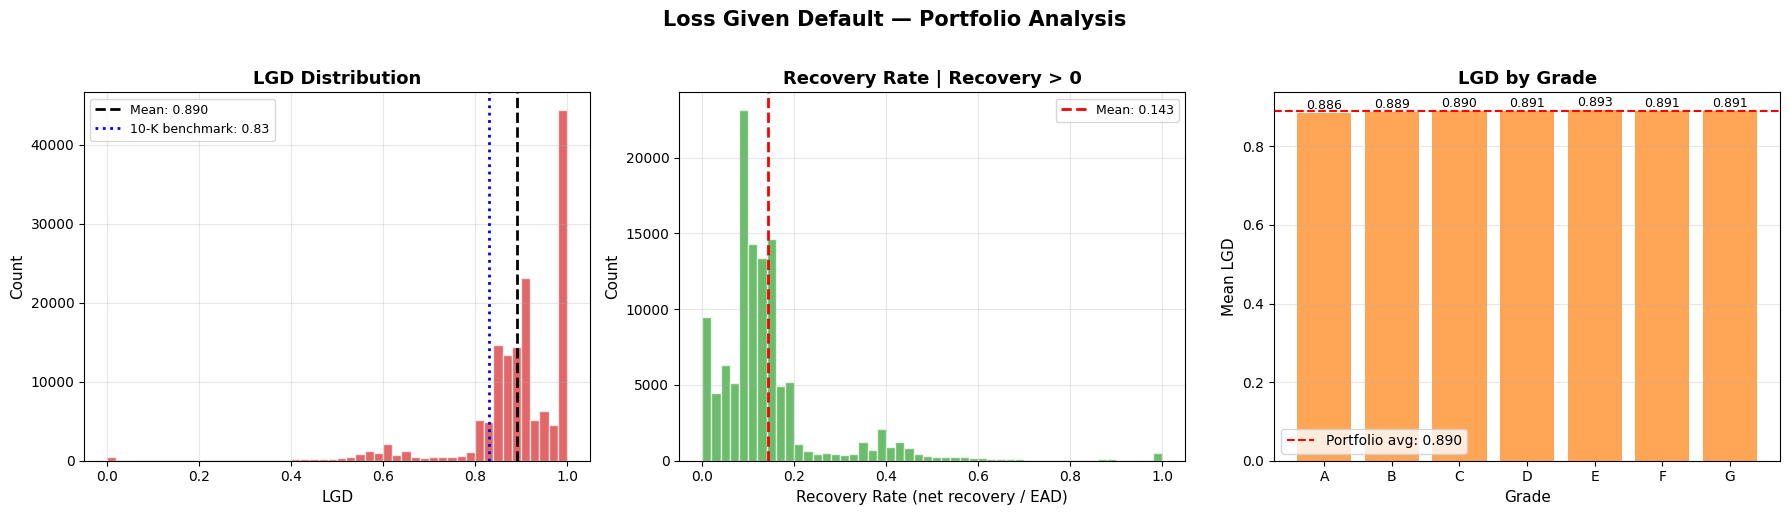

Saved: data/results/lgd_distributions.png


In [6]:
# LGD distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: LGD distribution
ax = axes[0]
ax.hist(train_def["lgd"], bins=50, color="#d62728", alpha=0.7, edgecolor="white")
ax.axvline(portfolio_lgd_mean, color="black", linestyle="--", linewidth=2,
           label=f"Mean: {portfolio_lgd_mean:.3f}")
ax.axvline(0.83, color="blue", linestyle=":", linewidth=2,
           label="10-K benchmark: 0.83")
ax.set_xlabel("LGD", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("LGD Distribution", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Recovery rate distribution (for loans with recovery)
ax = axes[1]
ax.hist(has_recovery["recovery_rate"], bins=50, color="#2ca02c", alpha=0.7, edgecolor="white")
ax.axvline(has_recovery["recovery_rate"].mean(), color="red", linestyle="--", linewidth=2,
           label=f"Mean: {has_recovery['recovery_rate'].mean():.3f}")
ax.set_xlabel("Recovery Rate (net recovery / EAD)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Recovery Rate | Recovery > 0", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: LGD by grade
ax = axes[2]
lgd_grade = lgd_by_grade(train_def["lgd"], train_def["grade"])
bars = ax.bar(lgd_grade["grade"], lgd_grade["mean_lgd"], color="#ff7f0e", alpha=0.7)
ax.axhline(portfolio_lgd_mean, color="red", linestyle="--", linewidth=1.5,
           label=f"Portfolio avg: {portfolio_lgd_mean:.3f}")
ax.set_xlabel("Grade", fontsize=11)
ax.set_ylabel("Mean LGD", fontsize=11)
ax.set_title("LGD by Grade", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
# Add value labels
for bar, val in zip(bars, lgd_grade["mean_lgd"]):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Loss Given Default — Portfolio Analysis", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig(DATA_RESULTS_PATH / "lgd_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/results/lgd_distributions.png")

In [7]:
# LGD by grade — detailed table
print("=" * 70)
print("LGD BY GRADE (Train)")
print("=" * 70)
print(f"{'Grade':<8s} {'Mean LGD':>10s} {'Median LGD':>12s} {'Recovery %':>12s} "
      f"{'Avg EAD ($)':>12s} {'Count':>8s}")
print("-" * 66)

prev_lgd = None
monotonic = True
lgd_by_grade_dict = {}

for g in GRADE_ORDER:
    subset = train_def[train_def["grade"] == g]
    if len(subset) == 0:
        continue
    mean_lgd = subset["lgd"].mean()
    median_lgd = subset["lgd"].median()
    recov_pct = subset["recovery_flag"].mean()
    avg_ead = subset["ead"].mean()

    # Check monotonicity
    flag = ""
    if prev_lgd is not None and mean_lgd < prev_lgd - 0.001:
        flag = " ↓"
        monotonic = False
    prev_lgd = mean_lgd

    lgd_by_grade_dict[g] = round(float(mean_lgd), 4)
    print(f"  {g:<6s} {mean_lgd:>10.4f} {median_lgd:>12.4f} {recov_pct:>12.2%} "
          f"${avg_ead:>11,.2f} {len(subset):>8,}{flag}")

print()
if monotonic:
    print("Monotonicity check: PASS (LGD increases A → G)")
else:
    print("Monotonicity check: Note — slight non-monotonicity observed.")
    print("  This is common in LGD models where recovery process is uniform")
    print("  across grades (same collection procedures applied to all).")

LGD BY GRADE (Train)
Grade      Mean LGD   Median LGD   Recovery %  Avg EAD ($)    Count
------------------------------------------------------------------
  A          0.8860       0.9198       71.18% $   6,790.98    8,020
  B          0.8888       0.9158       75.75% $   7,651.05   28,652
  C          0.8896       0.9138       77.66% $   9,077.72   45,378
  D          0.8914       0.9133       77.42% $  10,751.95   35,117
  E          0.8930       0.9126       76.80% $  13,452.66   22,551
  F          0.8907       0.9107       78.45% $  15,264.72    8,690 ↓
  G          0.8907       0.9093       80.65% $  16,671.23    2,258

Monotonicity check: Note — slight non-monotonicity observed.
  This is common in LGD models where recovery process is uniform
  across grades (same collection procedures applied to all).


## Step 5: Feature Preparation for LGD Model

Using origination features only (no post-default variables as predictors).
The model predicts LGD from information available at origination.

In [8]:
LGD_FEATURES = ["loan_amnt", "term", "grade_enc", "annual_inc", "dti",
                "fico_avg", "int_rate", "revol_util", "open_acc", "total_acc"]

# Encode grade
grade_le = LabelEncoder()
grade_le.fit(GRADE_ORDER)

for df in [train_def, val_def, test_def]:
    df["grade_enc"] = grade_le.transform(df["grade"])

# Impute missing values with training median
for col in LGD_FEATURES:
    n_miss = train_def[col].isna().sum()
    if n_miss > 0:
        med = train_def[col].median()
        print(f"  Imputing {col}: {n_miss:,} missing → median {med:.2f}")
        for df in [train_def, val_def, test_def]:
            df[col] = df[col].fillna(med)

print(f"\nLGD model features: {LGD_FEATURES}")
print(f"Feature count: {len(LGD_FEATURES)}")


LGD model features: ['loan_amnt', 'term', 'grade_enc', 'annual_inc', 'dti', 'fico_avg', 'int_rate', 'revol_util', 'open_acc', 'total_acc']
Feature count: 10


## Step 6: Stage 1 — Classification: P(Any Recovery)

Binary classification: does the charged-off loan have any net recovery?
- Target: `recovery_flag` = 1 if (recoveries - collection_recovery_fee) > 0
- Model: LogisticRegression with L2 regularization

In [9]:
# Prepare Stage 1 data
X_train = train_def[LGD_FEATURES].copy()
X_val   = val_def[LGD_FEATURES].copy()
X_test  = test_def[LGD_FEATURES].copy()

y_train_flag = train_def["recovery_flag"].copy()
y_val_flag   = val_def["recovery_flag"].copy()
y_test_flag  = test_def["recovery_flag"].copy()

print("Recovery flag distribution:")
for name, y in [("Train", y_train_flag), ("Val", y_val_flag), ("Test", y_test_flag)]:
    print(f"  {name}: {y.mean():.4f} ({y.sum():,} / {len(y):,} have recovery)")

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=LGD_FEATURES, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), columns=LGD_FEATURES, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=LGD_FEATURES, index=X_test.index
)

Recovery flag distribution:
  Train: 0.7686 (115,799 / 150,666 have recovery)
  Val: 0.6481 (43,854 / 67,661 have recovery)
  Test: 0.4882 (22,897 / 46,905 have recovery)


In [10]:
# Fit Stage 1 model
print("Training Stage 1: LogisticRegression for P(recovery)...")
t0 = time.time()

stage1_model = fit_lgd_stage1(
    X_train_scaled, y_train_flag,
    random_state=RANDOM_STATE,
)

s1_time = time.time() - t0
print(f"Trained in {s1_time:.1f}s")

# Stage 1 metrics
s1_train_proba = stage1_model.predict_proba(X_train_scaled)[:, 1]
s1_val_proba   = stage1_model.predict_proba(X_val_scaled)[:, 1]
s1_test_proba  = stage1_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 70)
print("STAGE 1 PERFORMANCE — P(Any Recovery)")
print("=" * 70)
print(f"{'Set':<15s} {'AUC':>10s} {'Accuracy':>10s} {'P(recov) avg':>15s}")
print("-" * 55)
for name, y_true, y_proba in [
    ("Train", y_train_flag, s1_train_proba),
    ("Validation", y_val_flag, s1_val_proba),
    ("Test", y_test_flag, s1_test_proba),
]:
    auc = roc_auc_score(y_true, y_proba)
    acc = accuracy_score(y_true, (y_proba >= 0.5).astype(int))
    print(f"{name:<15s} {auc:>10.4f} {acc:>10.4f} {y_proba.mean():>15.4f}")

# Coefficient interpretation
print(f"\nStage 1 coefficients:")
coef_df = pd.DataFrame({
    "feature": LGD_FEATURES,
    "coefficient": stage1_model.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)
for _, row in coef_df.iterrows():
    direction = "+" if row["coefficient"] > 0 else "-"
    print(f"  {row['feature']:<20s} {row['coefficient']:>+8.4f}  "
          f"({direction} → {'more' if row['coefficient'] > 0 else 'less'} likely to recover)")

Training Stage 1: LogisticRegression for P(recovery)...
Trained in 0.0s



STAGE 1 PERFORMANCE — P(Any Recovery)
Set                    AUC   Accuracy    P(recov) avg
-------------------------------------------------------


Train               0.6049     0.7686          0.7686
Validation          0.5562     0.6482          0.7862
Test                0.5222     0.4884          0.8067

Stage 1 coefficients:
  int_rate              +0.8341  (+ → more likely to recover)
  grade_enc             -0.6240  (- → less likely to recover)
  term                  -0.2367  (- → less likely to recover)
  annual_inc            +0.1329  (+ → more likely to recover)
  dti                   -0.1164  (- → less likely to recover)
  open_acc              -0.0700  (- → less likely to recover)
  revol_util            +0.0490  (+ → more likely to recover)
  total_acc             +0.0452  (+ → more likely to recover)
  loan_amnt             +0.0428  (+ → more likely to recover)
  fico_avg              +0.0052  (+ → more likely to recover)


## Step 7: Stage 2 — Regression: E[Recovery Rate | Recovery]

For loans with positive net recovery, predict the recovery rate.
- Target: `recovery_rate` = net_recovery / EAD, clipped to [0, 1]
- Model: GradientBoostingRegressor
- Only trained on loans where recovery_flag = 1

In [11]:
# Filter to recovery loans only
train_recov = train_def[train_def["recovery_flag"] == 1].copy()
val_recov   = val_def[val_def["recovery_flag"] == 1].copy()
test_recov  = test_def[test_def["recovery_flag"] == 1].copy()

X_train_s2 = train_recov[LGD_FEATURES].copy()
X_val_s2   = val_recov[LGD_FEATURES].copy()
X_test_s2  = test_recov[LGD_FEATURES].copy()

y_train_rr = train_recov["recovery_rate"].copy()
y_val_rr   = val_recov["recovery_rate"].copy()
y_test_rr  = test_recov["recovery_rate"].copy()

print(f"Recovery loans for Stage 2:")
print(f"  Train: {len(train_recov):,}")
print(f"  Val:   {len(val_recov):,}")
print(f"  Test:  {len(test_recov):,}")
print(f"\nRecovery rate distribution (Train):")
print(f"  Mean:   {y_train_rr.mean():.4f}")
print(f"  Median: {y_train_rr.median():.4f}")
print(f"  Std:    {y_train_rr.std():.4f}")
print(f"  P25:    {y_train_rr.quantile(0.25):.4f}")
print(f"  P75:    {y_train_rr.quantile(0.75):.4f}")

Recovery loans for Stage 2:
  Train: 115,799
  Val:   43,854
  Test:  22,897

Recovery rate distribution (Train):
  Mean:   0.1428
  Median: 0.1157
  Std:    0.1364
  P25:    0.0822
  P75:    0.1502


In [12]:
# Fit Stage 2 model
print("Training Stage 2: GradientBoostingRegressor for recovery rate...")
t0 = time.time()

stage2_model = fit_lgd_stage2(
    X_train_s2, y_train_rr,
    random_state=RANDOM_STATE,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_samples_leaf=50,
)

s2_time = time.time() - t0
print(f"Trained in {s2_time:.1f}s")

# Stage 2 predictions (recovery loans only)
s2_pred_train = np.clip(stage2_model.predict(X_train_s2), 0, 1)
s2_pred_val   = np.clip(stage2_model.predict(X_val_s2), 0, 1)
s2_pred_test  = np.clip(stage2_model.predict(X_test_s2), 0, 1)

print("\n" + "=" * 70)
print("STAGE 2 PERFORMANCE — E[Recovery Rate | Recovery]")
print("=" * 70)
print(f"{'Set':<15s} {'MAE':>10s} {'R²':>10s} {'Pred Mean':>12s} {'Actual Mean':>13s}")
print("-" * 65)
for name, y_true, y_pred in [
    ("Train", y_train_rr, s2_pred_train),
    ("Validation", y_val_rr, s2_pred_val),
    ("Test", y_test_rr, s2_pred_test),
]:
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:<15s} {mae:>10.4f} {r2:>10.4f} {y_pred.mean():>12.4f} {y_true.mean():>13.4f}")

# Feature importance
print(f"\nStage 2 feature importance (top 5):")
s2_importance = pd.Series(stage2_model.feature_importances_, index=LGD_FEATURES)
s2_importance = s2_importance.sort_values(ascending=False)
for feat, imp in s2_importance.head(5).items():
    print(f"  {feat:<20s} {imp:.4f}")

Training Stage 2: GradientBoostingRegressor for recovery rate...


Trained in 33.2s



STAGE 2 PERFORMANCE — E[Recovery Rate | Recovery]
Set                    MAE         R²    Pred Mean   Actual Mean
-----------------------------------------------------------------
Train               0.0811     0.0346       0.1428        0.1428
Validation          0.0719    -0.0004       0.1461        0.1393
Test                0.0459    -0.1363       0.1419        0.1196

Stage 2 feature importance (top 5):
  int_rate             0.2824
  dti                  0.1219
  loan_amnt            0.0976
  fico_avg             0.0965
  annual_inc           0.0941


## Step 8: Combined Two-Stage LGD Prediction

LGD = 1 - P(recovery) × E[recovery_rate | recovery]

This combines Stage 1 (probability of any recovery) with Stage 2
(expected recovery rate conditional on recovery occurring).

In [13]:
# Combined predictions — Stage 1 uses scaled features, Stage 2 uses raw
# For the combined predict_lgd function, we need consistent inputs.
# We'll compute each stage separately here for clarity.

def combined_lgd_predict(stage1, stage2, X_scaled, X_raw):
    """Two-stage LGD prediction with separate scaling."""
    p_recovery = stage1.predict_proba(X_scaled)[:, 1]
    e_recovery_rate = np.clip(stage2.predict(X_raw), 0, 1)
    lgd = 1 - p_recovery * e_recovery_rate
    return np.clip(lgd, 0, 1)


lgd_pred_train = combined_lgd_predict(stage1_model, stage2_model, X_train_scaled, X_train)
lgd_pred_val   = combined_lgd_predict(stage1_model, stage2_model, X_val_scaled, X_val)
lgd_pred_test  = combined_lgd_predict(stage1_model, stage2_model, X_test_scaled, X_test)

# Actual LGD
lgd_actual_train = train_def["lgd"].values
lgd_actual_val   = val_def["lgd"].values
lgd_actual_test  = test_def["lgd"].values

print("=" * 80)
print("COMBINED TWO-STAGE LGD MODEL PERFORMANCE")
print("=" * 80)
print(f"{'Set':<15s} {'MAE':>10s} {'R²':>10s} {'Pred Mean':>12s} "
      f"{'Actual Mean':>13s} {'Target':>10s}")
print("-" * 75)

combined_results = []
for name, y_true, y_pred in [
    ("Train", lgd_actual_train, lgd_pred_train),
    ("Validation", lgd_actual_val, lgd_pred_val),
    ("Test", lgd_actual_test, lgd_pred_test),
]:
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    target = "< 0.10" if name == "Test" else ""
    combined_results.append({"set": name, "MAE": mae, "R2": r2,
                             "pred_mean": y_pred.mean(), "actual_mean": y_true.mean()})
    print(f"{name:<15s} {mae:>10.4f} {r2:>10.4f} {y_pred.mean():>12.4f} "
          f"{y_true.mean():>13.4f} {target:>10s}")

test_mae = combined_results[2]["MAE"]
status = "PASS" if test_mae < 0.10 else "MISS"
print(f"\nMAE Target: {test_mae:.4f} — {status}")

# Portfolio average LGD from model
model_lgd = lgd_pred_train.mean()
print(f"\nModel portfolio LGD (train): {model_lgd:.4f}")
print(f"Actual portfolio LGD (train): {lgd_actual_train.mean():.4f}")
print(f"10-K benchmark: 0.83")
print(f"\nDefault recovery_rate seed: {1 - model_lgd:.4f}")
print(f"  (LGD ≈ {model_lgd:.2f} → recovery_rate ≈ {1 - model_lgd:.2f})")

COMBINED TWO-STAGE LGD MODEL PERFORMANCE
Set                    MAE         R²    Pred Mean   Actual Mean     Target
---------------------------------------------------------------------------
Train               0.0835     0.0185       0.8897        0.8903           
Validation          0.0793    -0.0518       0.8851        0.9097           
Test                0.0757    -0.5502       0.8854        0.9416     < 0.10

MAE Target: 0.0757 — PASS

Model portfolio LGD (train): 0.8897
Actual portfolio LGD (train): 0.8903
10-K benchmark: 0.83

Default recovery_rate seed: 0.1103
  (LGD ≈ 0.89 → recovery_rate ≈ 0.11)


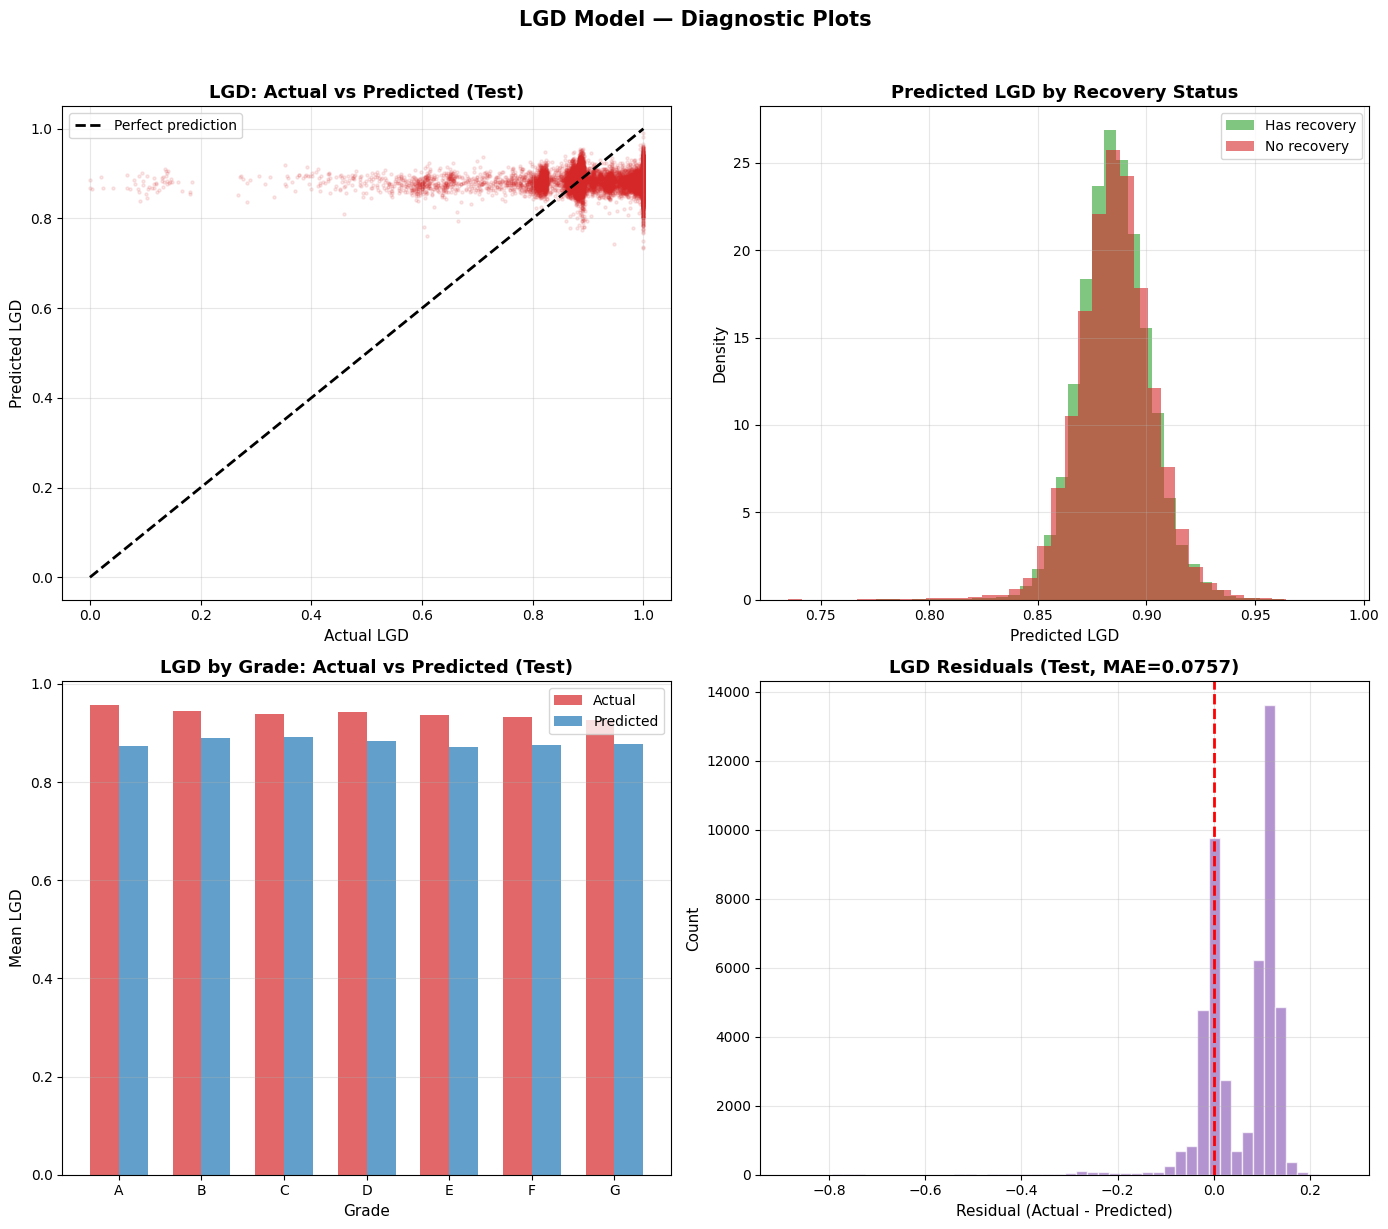

Saved: data/results/lgd_model_diagnostics.png


In [14]:
# LGD diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Actual vs Predicted LGD
ax = axes[0, 0]
ax.scatter(lgd_actual_test, lgd_pred_test, alpha=0.1, s=5, color="#d62728")
ax.plot([0, 1], [0, 1], "k--", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual LGD", fontsize=11)
ax.set_ylabel("Predicted LGD", fontsize=11)
ax.set_title("LGD: Actual vs Predicted (Test)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Predicted LGD distribution by actual outcome
ax = axes[0, 1]
# Split by whether loan had any recovery
has_recov_test = test_def["recovery_flag"] == 1
ax.hist(lgd_pred_test[has_recov_test], bins=40, alpha=0.6, label="Has recovery",
        color="#2ca02c", density=True)
ax.hist(lgd_pred_test[~has_recov_test], bins=40, alpha=0.6, label="No recovery",
        color="#d62728", density=True)
ax.set_xlabel("Predicted LGD", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Predicted LGD by Recovery Status", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: LGD by grade — actual vs predicted
ax = axes[1, 0]
lgd_grade_actual = lgd_by_grade(pd.Series(lgd_actual_test, index=test_def.index),
                                test_def["grade"])
lgd_grade_pred = lgd_by_grade(pd.Series(lgd_pred_test, index=test_def.index),
                              test_def["grade"])
x = np.arange(len(lgd_grade_actual))
width = 0.35
bars1 = ax.bar(x - width/2, lgd_grade_actual["mean_lgd"], width, label="Actual",
               color="#d62728", alpha=0.7)
bars2 = ax.bar(x + width/2, lgd_grade_pred["mean_lgd"], width, label="Predicted",
               color="#1f77b4", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(lgd_grade_actual["grade"])
ax.set_xlabel("Grade", fontsize=11)
ax.set_ylabel("Mean LGD", fontsize=11)
ax.set_title("LGD by Grade: Actual vs Predicted (Test)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# Plot 4: Residual distribution
ax = axes[1, 1]
residuals = lgd_actual_test - lgd_pred_test
ax.hist(residuals, bins=50, color="#9467bd", alpha=0.7, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=2)
ax.set_xlabel("Residual (Actual - Predicted)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"LGD Residuals (Test, MAE={test_mae:.4f})", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)

fig.suptitle("LGD Model — Diagnostic Plots", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig(DATA_RESULTS_PATH / "lgd_model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/results/lgd_model_diagnostics.png")

## Step 9: LGD Sanity Checks and Benchmark Comparison

### Benchmark: LendingClub 10-K
From the 10-K: $49M recovery / $286M gross ALLL → LGD ≈ 0.83.

Our model's portfolio LGD is computed as:
- LGD = 1 - (net post-charge-off recovery / reconstructed EAD)

The difference from 0.83 reflects:
1. Different time periods (10-K covers specific fiscal year vs our 2007-2015 training window)
2. EAD reconstruction method (amortization schedule vs actual charge-off balance)
3. Net recovery definition (we deduct collection fees; 10-K may report gross)

In [15]:
print("=" * 70)
print("LGD SANITY CHECKS")
print("=" * 70)
print()

# 1. Portfolio average
actual_lgd_mean = lgd_actual_train.mean()
print(f"1. Portfolio Average LGD")
print(f"   Observed (train):  {actual_lgd_mean:.4f}")
print(f"   Model (train):     {model_lgd:.4f}")
print(f"   10-K benchmark:    0.8300")
print(f"   Difference:        {actual_lgd_mean - 0.83:+.4f}")
print()

# 2. Recovery rate seed
recovery_rate_seed = 1 - actual_lgd_mean
print(f"2. Default Recovery Rate Seed")
print(f"   recovery_rate = 1 - LGD = {recovery_rate_seed:.4f}")
print(f"   → Use {recovery_rate_seed:.2f} as default recovery assumption for ECL")
print()

# 3. Grade monotonicity
print(f"3. LGD by Grade (Monotonicity):")
lgd_grades = lgd_by_grade(pd.Series(lgd_actual_train), train_def["grade"])
prev = None
all_mono = True
for _, row in lgd_grades.iterrows():
    if pd.isna(row["mean_lgd"]):
        continue
    flag = ""
    if prev is not None and row["mean_lgd"] < prev - 0.001:
        flag = " ← non-monotonic"
        all_mono = False
    prev = row["mean_lgd"]
    print(f"   Grade {row['grade']}: {row['mean_lgd']:.4f}{flag}")
print(f"   Monotonic: {'Yes' if all_mono else 'Approximately — see note above'}")
print()

# 4. Segmented validation
print(f"4. LGD by Term:")
for t in sorted(train_def["term"].unique()):
    subset = train_def[train_def["term"] == t]
    print(f"   {int(t):>2d} months: LGD = {subset['lgd'].mean():.4f}  (n = {len(subset):,})")
print()

# 5. Out-of-time stability
print(f"5. Out-of-Time LGD Stability:")
print(f"   Train (2007-2015):  {lgd_actual_train.mean():.4f}")
print(f"   Val (2016):         {lgd_actual_val.mean():.4f}")
print(f"   Test (2017-2018):   {lgd_actual_test.mean():.4f}")
print(f"   Drift (train→test): {lgd_actual_test.mean() - lgd_actual_train.mean():+.4f}")

LGD SANITY CHECKS

1. Portfolio Average LGD
   Observed (train):  0.8903
   Model (train):     0.8897
   10-K benchmark:    0.8300
   Difference:        +0.0603

2. Default Recovery Rate Seed
   recovery_rate = 1 - LGD = 0.1097
   → Use 0.11 as default recovery assumption for ECL

3. LGD by Grade (Monotonicity):
   Grade A: 0.8867
   Grade B: 0.8917
   Grade C: 0.8917
   Grade D: 0.8892 ← non-monotonic
   Grade E: 0.8930
   Grade F: 0.8838 ← non-monotonic
   Grade G: 0.8939
   Monotonic: Approximately — see note above

4. LGD by Term:
   36 months: LGD = 0.8833  (n = 84,553)
   60 months: LGD = 0.8991  (n = 66,113)

5. Out-of-Time LGD Stability:
   Train (2007-2015):  0.8903
   Val (2016):         0.9097
   Test (2017-2018):   0.9416
   Drift (train→test): +0.0514


## Step 10: Save Models and Metrics

In [16]:
# Ensure output directories exist
DATA_MODELS_PATH.mkdir(parents=True, exist_ok=True)
DATA_RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# Save Stage 1 model
s1_path = DATA_MODELS_PATH / "lgd_stage1_model.pkl"
with open(s1_path, "wb") as f:
    pickle.dump({"model": stage1_model, "scaler": scaler}, f)
print(f"Saved: {s1_path}")

# Save Stage 2 model
s2_path = DATA_MODELS_PATH / "lgd_stage2_model.pkl"
with open(s2_path, "wb") as f:
    pickle.dump(stage2_model, f)
print(f"Saved: {s2_path}")

# Save metrics
lgd_output = {
    "model": "Two-Stage (LogisticRegression + GradientBoostingRegressor)",
    "features": LGD_FEATURES,
    "n_features": len(LGD_FEATURES),
    "portfolio_avg_lgd": round(float(actual_lgd_mean), 4),
    "portfolio_avg_lgd_model": round(float(model_lgd), 4),
    "benchmark_lgd": 0.83,
    "default_recovery_rate": round(float(recovery_rate_seed), 4),
    "lgd_by_grade": lgd_by_grade_dict,
    "stage1": {
        "model": "LogisticRegression",
        "target": "recovery_flag (binary)",
        "train_auc": round(float(roc_auc_score(y_train_flag, s1_train_proba)), 4),
        "val_auc": round(float(roc_auc_score(y_val_flag, s1_val_proba)), 4),
        "test_auc": round(float(roc_auc_score(y_test_flag, s1_test_proba)), 4),
        "recovery_rate_train": round(float(y_train_flag.mean()), 4),
    },
    "stage2": {
        "model": "GradientBoostingRegressor",
        "target": "recovery_rate (continuous, [0,1])",
        "train_mae": round(float(mean_absolute_error(y_train_rr, s2_pred_train)), 4),
        "val_mae": round(float(mean_absolute_error(y_val_rr, s2_pred_val)), 4),
        "test_mae": round(float(mean_absolute_error(y_test_rr, s2_pred_test)), 4),
        "train_r2": round(float(r2_score(y_train_rr, s2_pred_train)), 4),
        "test_r2": round(float(r2_score(y_test_rr, s2_pred_test)), 4),
    },
    "combined": {
        "formula": "LGD = 1 - P(recovery) * E[recovery_rate | recovery]",
        "train_mae": round(float(combined_results[0]["MAE"]), 4),
        "val_mae": round(float(combined_results[1]["MAE"]), 4),
        "test_mae": round(float(combined_results[2]["MAE"]), 4),
        "train_r2": round(float(combined_results[0]["R2"]), 4),
        "test_r2": round(float(combined_results[2]["R2"]), 4),
    },
    "mae_target": 0.10,
    "mae_achieved": round(float(test_mae), 4),
    "target_met": bool(test_mae < 0.10),
    "n_train": len(train_def),
    "n_val": len(val_def),
    "n_test": len(test_def),
}

lgd_metrics_path = DATA_RESULTS_PATH / "lgd_metrics.json"
with open(lgd_metrics_path, "w") as f:
    json.dump(lgd_output, f, indent=2)
print(f"Saved: {lgd_metrics_path}")

Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/models/lgd_stage1_model.pkl
Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/models/lgd_stage2_model.pkl
Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/results/lgd_metrics.json


In [17]:
# ── Final Summary ──

print("=" * 80)
print("NOTEBOOK 06 SUMMARY — Loss Given Default (LGD) Model")
print("=" * 80)
print()
print(f"{'Metric':<35s} {'Value':>15s}")
print("-" * 53)
print(f"{'Portfolio Avg LGD (observed)':<35s} {actual_lgd_mean:>15.4f}")
print(f"{'Portfolio Avg LGD (model)':<35s} {model_lgd:>15.4f}")
print(f"{'10-K Benchmark':<35s} {'0.8300':>15s}")
print(f"{'Default Recovery Rate Seed':<35s} {recovery_rate_seed:>15.4f}")
print(f"{'Test MAE (combined)':<35s} {test_mae:>15.4f}")
print(f"{'MAE Target (< 0.10)':<35s} {status:>15s}")
print(f"{'Stage 1 Test AUC':<35s} {roc_auc_score(y_test_flag, s1_test_proba):>15.4f}")
print(f"{'Stage 2 Test MAE':<35s} {mean_absolute_error(y_test_rr, s2_pred_test):>15.4f}")
print()
print("LGD by Grade (A-G):")
for g, v in lgd_by_grade_dict.items():
    print(f"  Grade {g}: {v:.4f}")
print()
print("Two-Stage Model:")
print(f"  Stage 1: LogisticRegression → P(recovery) = {s1_test_proba.mean():.4f}")
print(f"  Stage 2: GBR → E[recovery_rate | recovery] = {s2_pred_test.mean():.4f}")
print(f"  Combined: LGD = 1 - {s1_test_proba.mean():.4f} × {s2_pred_test.mean():.4f}")
print()
print("Files saved:")
print("  data/models/lgd_stage1_model.pkl  (LogisticRegression + scaler)")
print("  data/models/lgd_stage2_model.pkl  (GradientBoostingRegressor)")
print("  data/results/lgd_metrics.json")
print("  data/results/lgd_distributions.png")
print("  data/results/lgd_model_diagnostics.png")
print()
print("→ Next: Notebook 05.5 — Prepayment Model (CPR)")

NOTEBOOK 06 SUMMARY — Loss Given Default (LGD) Model

Metric                                        Value
-----------------------------------------------------
Portfolio Avg LGD (observed)                 0.8903
Portfolio Avg LGD (model)                    0.8897
10-K Benchmark                               0.8300
Default Recovery Rate Seed                   0.1097
Test MAE (combined)                          0.0757
MAE Target (< 0.10)                            PASS
Stage 1 Test AUC                             0.5222
Stage 2 Test MAE                             0.0459

LGD by Grade (A-G):
  Grade A: 0.8860
  Grade B: 0.8888
  Grade C: 0.8896
  Grade D: 0.8914
  Grade E: 0.8930
  Grade F: 0.8907
  Grade G: 0.8907

Two-Stage Model:
  Stage 1: LogisticRegression → P(recovery) = 0.8067
  Stage 2: GBR → E[recovery_rate | recovery] = 0.1419
  Combined: LGD = 1 - 0.8067 × 0.1419

Files saved:
  data/models/lgd_stage1_model.pkl  (LogisticRegression + scaler)
  data/models/lgd_stage2_model.pkl